<a href="https://colab.research.google.com/github/Scanfmonse/ExamenCompiladores/blob/master/TareaDigitos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

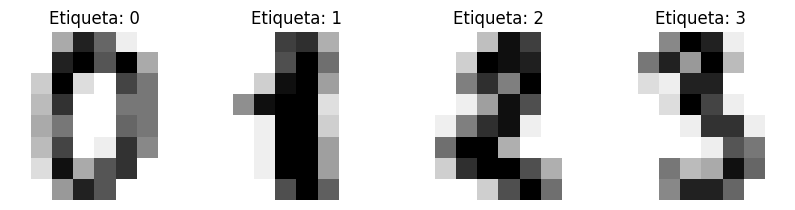

Total de muestras de entrenamiento: 1437
Total de muestras de prueba: 360


In [17]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# --- 1. Carga del dataset ---
digits = load_digits()

X = digits.data
y = digits.target

fig, axes = plt.subplots(1, 4, figsize=(10, 3))
for ax, image, label in zip(axes, digits.images[:4], y[:4]):
    ax.set_axis_off()
    ax.imshow(image, cmap=plt.cm.gray_r, interpolation='nearest')
    ax.set_title(f'Etiqueta: {label}')
plt.show()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Total de muestras de entrenamiento: {X_train.shape[0]}")
print(f"Total de muestras de prueba: {X_test.shape[0]}")

In [18]:
# --- 2. Entrenamiento de modelos ---

# K-Nearest Neighbors (k=5)
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)

# Support Vector Machine (Kernel RBF)
svm_model = SVC(kernel='rbf', gamma='scale', random_state=42)
svm_model.fit(X_train, y_train)

# Random Forest (100 estimadores)
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

print("¡Entrenamiento de los tres modelos completado!")

¡Entrenamiento de los tres modelos completado!


In [19]:
# --- 3. Evaluación ---

# Realizar predicciones con el conjunto de prueba
y_pred_knn = knn_model.predict(X_test)
y_pred_svm = svm_model.predict(X_test)
y_pred_rf = rf_model.predict(X_test)

# Calcular exactitud (accuracy)
acc_knn = accuracy_score(y_test, y_pred_knn)
acc_svm = accuracy_score(y_test, y_pred_svm)
acc_rf = accuracy_score(y_test, y_pred_rf)

print("--- Resultados de Exactitud (Accuracy) ---")
print(f"KNN (k=5):      {acc_knn * 100:.2f}%")
print(f"SVM (RBF):      {acc_svm * 100:.2f}%")
print(f"Random Forest:  {acc_rf * 100:.2f}%")

# Identificar el mejor
resultados = {'KNN': acc_knn, 'SVM': acc_svm, 'Random Forest': acc_rf}
mejor_modelo = max(resultados, key=resultados.get)
print(f"\nEl mejor modelo en el conjunto de prueba es: {mejor_modelo}")

--- Resultados de Exactitud (Accuracy) ---
KNN (k=5):      98.61%
SVM (RBF):      98.61%
Random Forest:  97.22%

El mejor modelo en el conjunto de prueba es: KNN


--- RESULTADOS DE CLASIFICACIÓN ---

Archivo: imagen1.png
Dígito Real: 0
  -> Predicción KNN: 0
  -> Predicción SVM: 3
  -> Predicción Random Forest: 0
----------------------------------------
Archivo: imagen2.png
Dígito Real: 1
  -> Predicción KNN: 2
  -> Predicción SVM: 2
  -> Predicción Random Forest: 2
----------------------------------------
Archivo: imagen3.png
Dígito Real: 7
  -> Predicción KNN: 7
  -> Predicción SVM: 7
  -> Predicción Random Forest: 7
----------------------------------------


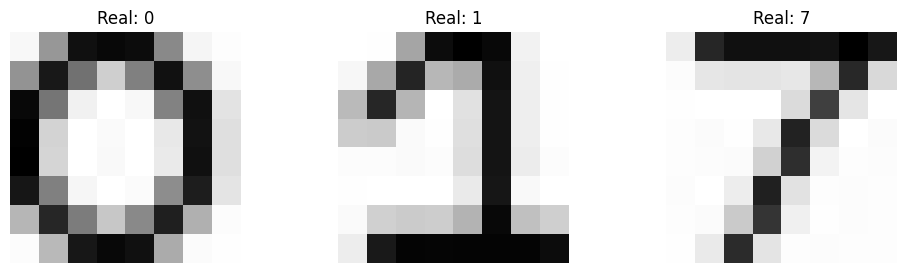

In [20]:
import matplotlib.pyplot as plt

# 1. Define los nombres de tus archivos subidos a Colab
archivos = ['imagen1.png', 'imagen2.png', 'imagen3.png'] # Cámbialos por tus nombres reales

# 2. Define qué dígito dibujaste en cada imagen para comparar
etiquetas_reales = [0, 1, 7] # Cambia estos números según lo que hayas dibujado

# Preparamos una figura para visualizar las 3 imágenes procesadas
fig, axes = plt.subplots(1, 3, figsize=(12, 3))

print("--- RESULTADOS DE CLASIFICACIÓN ---\n")

for i, (archivo, etiqueta_real) in enumerate(zip(archivos, etiquetas_reales)):

    # Procesamos la imagen usando la función que definimos antes
    img_procesada = procesar_mi_imagen(archivo)

    # Visualización en la gráfica
    ax = axes[i]
    ax.set_axis_off()
    # Volvemos a darle forma de 8x8 solo para dibujarla
    ax.imshow(img_procesada.reshape(8, 8), cmap=plt.cm.gray_r)
    ax.set_title(f'Real: {etiqueta_real}')

    # Preparamos el arreglo para los modelos (1 fila, 64 columnas)
    img_input = img_procesada.reshape(1, -1)

    # Hacemos las predicciones
    pred_knn = knn_model.predict(img_input)[0]
    pred_svm = svm_model.predict(img_input)[0]
    pred_rf = rf_model.predict(img_input)[0]

    # Imprimimos los resultados de cada imagen
    print(f"Archivo: {archivo}")
    print(f"Dígito Real: {etiqueta_real}")
    print(f"  -> Predicción KNN: {pred_knn}")
    print(f"  -> Predicción SVM: {pred_svm}")
    print(f"  -> Predicción Random Forest: {pred_rf}")
    print("-" * 40)

# Mostramos las imágenes procesadas para comprobar que se ven bien
plt.show()

--- Resultados para imagen1.png ---
Dígito Real esperado: 0
  -> Predicción KNN: 0
  -> Predicción SVM: 3
  -> Predicción RF:  0


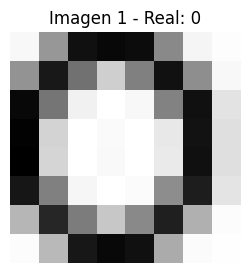

In [21]:
archivo_1 = 'imagen1.png'
etiqueta_real_1 = 0

# Procesamiento
img_procesada_1 = procesar_mi_imagen(archivo_1)
img_input_1 = img_procesada_1.reshape(1, -1)

# Predicciones
print(f"--- Resultados para {archivo_1} ---")
print(f"Dígito Real esperado: {etiqueta_real_1}")
print(f"  -> Predicción KNN: {knn_model.predict(img_input_1)[0]}")
print(f"  -> Predicción SVM: {svm_model.predict(img_input_1)[0]}")
print(f"  -> Predicción RF:  {rf_model.predict(img_input_1)[0]}")

# Visualización
plt.figure(figsize=(3, 3))
plt.imshow(img_procesada_1.reshape(8, 8), cmap=plt.cm.gray_r)
plt.title(f'Imagen 1 - Real: {etiqueta_real_1}')
plt.axis('off')
plt.show()

--- Resultados para imagen2.png ---
Dígito Real esperado: 1
  -> Predicción KNN: 2
  -> Predicción SVM: 2
  -> Predicción RF:  2


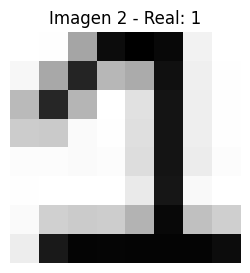

In [22]:
archivo_2 = 'imagen2.png'
etiqueta_real_2 = 1

# Procesamiento
img_procesada_2 = procesar_mi_imagen(archivo_2)
img_input_2 = img_procesada_2.reshape(1, -1)

# Predicciones
print(f"--- Resultados para {archivo_2} ---")
print(f"Dígito Real esperado: {etiqueta_real_2}")
print(f"  -> Predicción KNN: {knn_model.predict(img_input_2)[0]}")
print(f"  -> Predicción SVM: {svm_model.predict(img_input_2)[0]}")
print(f"  -> Predicción RF:  {rf_model.predict(img_input_2)[0]}")

# Visualización
plt.figure(figsize=(3, 3))
plt.imshow(img_procesada_2.reshape(8, 8), cmap=plt.cm.gray_r)
plt.title(f'Imagen 2 - Real: {etiqueta_real_2}')
plt.axis('off')
plt.show()

--- Resultados para imagen3.png ---
Dígito Real esperado: 7
  -> Predicción KNN: 7
  -> Predicción SVM: 7
  -> Predicción RF:  7


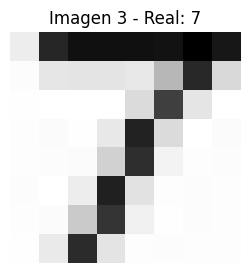

In [23]:
archivo_3 = 'imagen3.png'
etiqueta_real_3 = 7

# Procesamiento
img_procesada_3 = procesar_mi_imagen(archivo_3)
img_input_3 = img_procesada_3.reshape(1, -1)

# Predicciones
print(f"--- Resultados para {archivo_3} ---")
print(f"Dígito Real esperado: {etiqueta_real_3}")
print(f"  -> Predicción KNN: {knn_model.predict(img_input_3)[0]}")
print(f"  -> Predicción SVM: {svm_model.predict(img_input_3)[0]}")
print(f"  -> Predicción RF:  {rf_model.predict(img_input_3)[0]}")

# Visualización
plt.figure(figsize=(3, 3))
plt.imshow(img_procesada_3.reshape(8, 8), cmap=plt.cm.gray_r)
plt.title(f'Imagen 3 - Real: {etiqueta_real_3}')
plt.axis('off')
plt.show()